In [ ]:
# WEEK 2 : LOADING & CLEANING DATASET

import pandas as pd
data = pd.read_csv('C:/Users/HP/Desktop/DSA1080B-SS2026-Anthony-ChicagoCrime/data/Crimes_-_2026_20260317.csv')
data.head()
data.info()

# 1.Converting Date to a proper datetime format
data['Date'] = pd.to_datetime(data['Date'], format = '%m/%d/%Y %I:%M:%S %p')

# 2.Handling missind values in Location Description
data['Location Description'] = data['Location Description'].fillna('UNKNOWM')

# 3.Droping rows where coordinates are missing
data.dropna(subset = ['Latitude', 'Location'], inplace = True)

# 4.Checking and removing duplicates
data.drop_duplicates(subset='ID', inplace = True)

# 5.Creating more specific columns for in-depth analysis
data['Hour'] = data['Date'].dt.hour
data['Day'] = data['Date'].dt.day_name()
data['Month'] = data['Date'].dt.month

# Confirming changes
data.info()
# Saving cleaned dataset
data.to_csv('data/cleaned_dataset.csv', index = False)


In [14]:
# WEEK 3 : EXPLORATORY DATA ANALYSIS
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setting visual style
sns.set_theme(style = 'whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

data = pd.read_csv('data/cleaned_dataset.csv')

C:\Users\HP\AppData\Local\Temp\ipykernel_18996\1082976259.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_crimes.values, y=top_10_crimes.index, palette = 'magma')


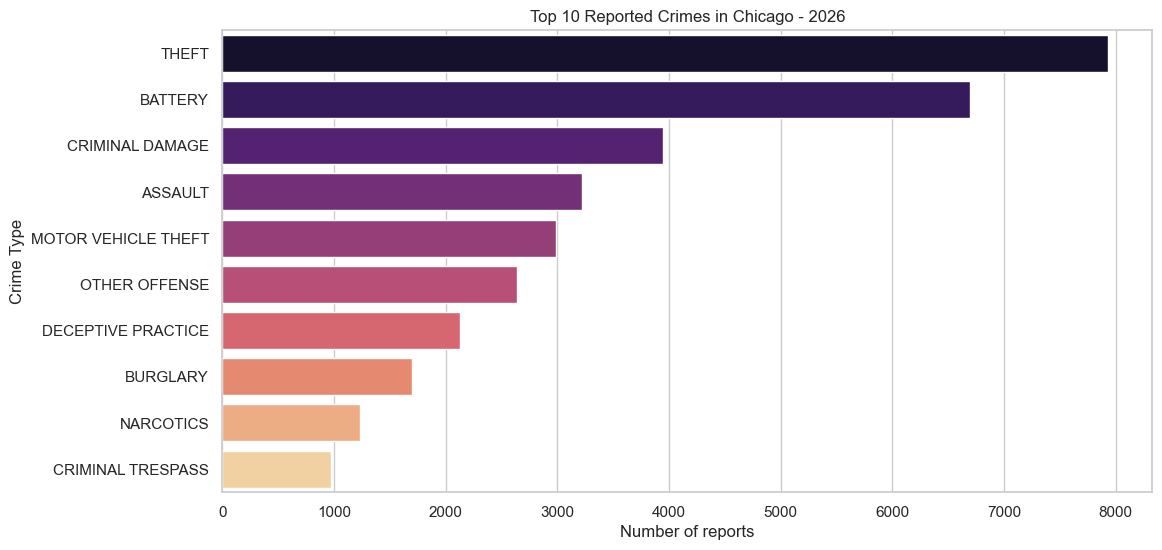

In [15]:
# Insight 1 : Top 10 crime types
top_10_crimes = data['Primary Type'].value_counts().head(10)

sns.barplot(x=top_10_crimes.values, y=top_10_crimes.index, palette = 'magma')
plt.title('Top 10 Reported Crimes in Chicago - 2026')
plt.xlabel('Number of reports')
plt.ylabel('Crime Type')

plt.savefig('visuals/top_10_crimes.png', bbox_inches='tight')
plt.show()

Observation: The bar chart shows that Theft and Battery are the most frequently reported crimes in 2026 so far.
Analysis: High levels of theft usually correlate with high-density commercial areas. This shows that property-related crimes are the main concern for an average citizen

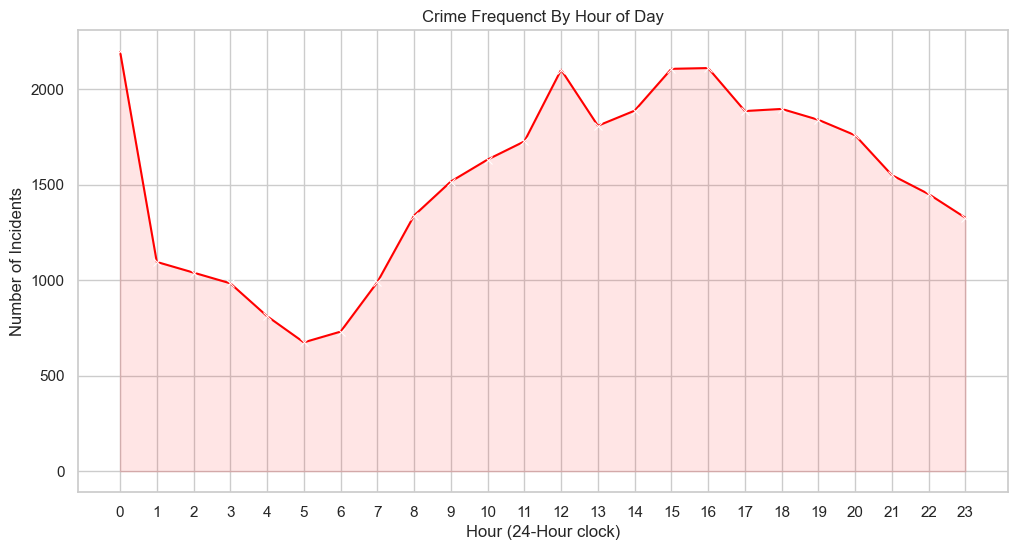

In [ ]:
# Insight 2 : Hourly Distribution of Crimes
hourly_counts = data.groupby('Hour').size()

sns.lineplot(x=hourly_counts.index, y=hourly_counts.values, marker = 'x', color = 'red')
plt.fill_between(hourly_counts.index, hourly_counts.values, color = 'red', alpha = 0.1)
plt.xticks(range(0, 24))
plt.title('Crime Frequenct By Hour of Day')
plt.xlabel('Hour (24-Hour clock)')
plt.ylabel('Number of Incidents')

plt.savefig('visuals/hourly_distribution.png')

Observation: Crime incidents appear to follow a trend with a 'U' shape. Activity is lowest between 3AM and 6AM. A steady climb can be observed afterwards which peaks in the late evening.
Analysis: The peak in the evening suggests criminal activity is more prevalent during periods of low natural light and higher social activity. This could be vital in informing shift scheduling

C:\Users\HP\AppData\Local\Temp\ipykernel_18996\1480411680.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=arrest_rate.values, y=arrest_rate.index, palette='viridis')


<function matplotlib.pyplot.show(close=None, block=None)>

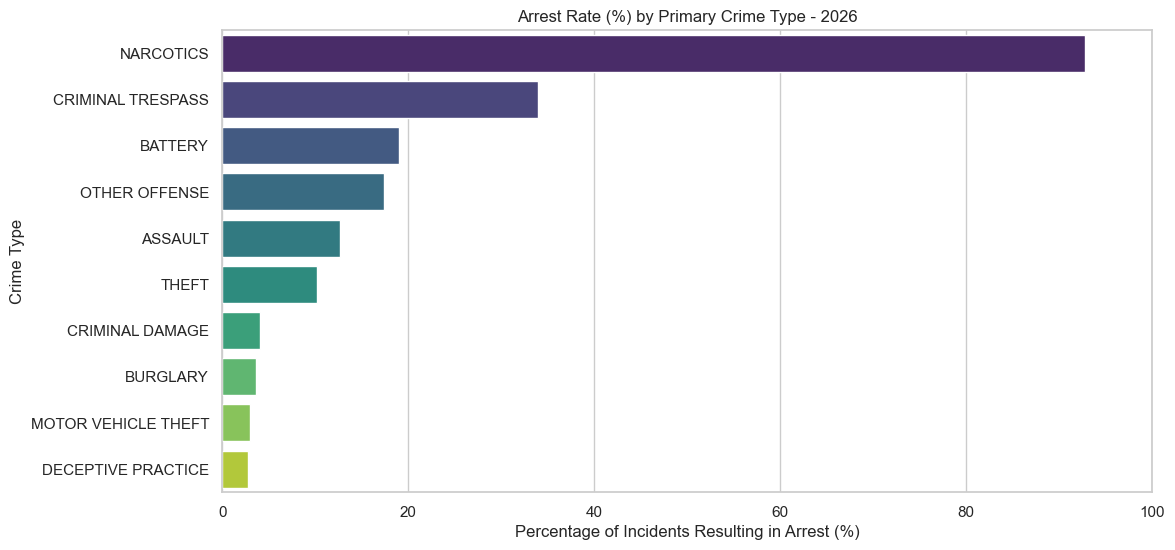

In [21]:
# Insight 3 : Arrest Rates by Category
top_crimes = data['Primary Type'].value_counts().head(10).index
arrest_data = data[data['Primary Type'].isin(top_crimes)]

arrest_rate = (arrest_data.groupby('Primary Type')['Arrest'].mean() * 100).sort_values(ascending = False)

sns.barplot(x=arrest_rate.values, y=arrest_rate.index, palette='viridis')
plt.title('Arrest Rate (%) by Primary Crime Type - 2026')
plt.xlabel('Percentage of Incidents Resulting in Arrest (%)')
plt.ylabel('Crime Type')
plt.xlim(0, 100)

plt.savefig('visuals/arrest_rate_by_crime.png', bbox_inches='tight')
plt.show

Observation: There is a bid difference in arrest rates across crime categories. While narcotics offenses show an arrest rate near 90%, theft and burglary are below 10%.
Analysis: This indicates that crimes police see happening, like drug deals, are much easier to clear than crimes reported after their occurence such as breal-ins.

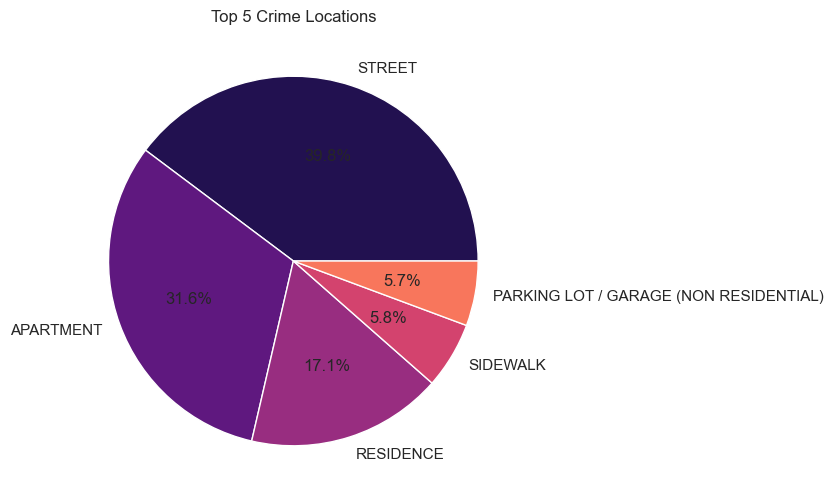

In [23]:
# Insight 4 - Location Analysis
top_locations = data['Location Description'].value_counts().head(5)

plt.figure(figsize=(10, 6))
plt.pie(top_locations, labels=top_locations.index, autopct='%1.1f%%', colors=sns.color_palette('magma'))
plt.title('Top 5 Crime Locations')

plt.savefig('visuals/top_locations.png')
plt.show()

**Observation**: Chart shows a high number of crimes in the streets followed by apartments
**Analysis**: This shows that increased street patrols would prove very useful in deterring street crimes which has proven to be prevalent relative to the rest. Addressing battery and domestic incidents requires targeted community-based intervention rather than just increased police visibility on sidewalks.

C:\Users\HP\AppData\Local\Temp\ipykernel_18996\1115768453.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = data, x='Domestic', palette='Set2')


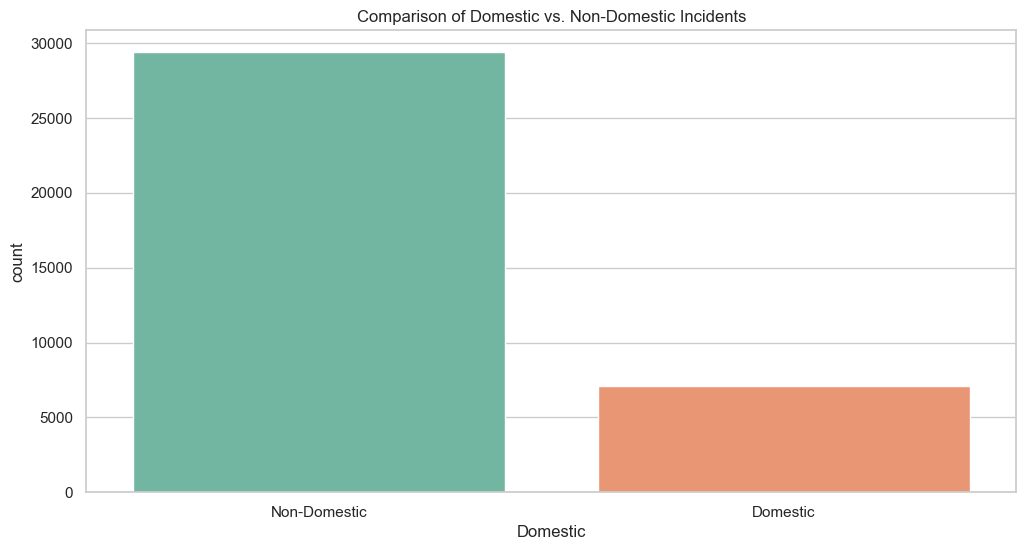

In [25]:
# Insight 5 : Domestic vs Non-Domestic Analysis
sns.countplot(data = data, x='Domestic', palette='Set2')
plt.title('Comparison of Domestic vs. Non-Domestic Incidents')
plt.xticks([0, 1], ['Non-Domestic', 'Domestic'])

plt.savefig('visuals/domestic_ratio.png')
plt.show()

Observation: The ratio of non-domestic to domestic crimes is almost 1:6.
Analysis: This shows that criminal activity is mainly tied to encounters with strangers rather than in the household.

C:\Users\HP\AppData\Local\Temp\ipykernel_13156\646327095.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=district_analysis.index.astype(str), y=district_analysis['Arrest Rate'], palette='coolwarm')


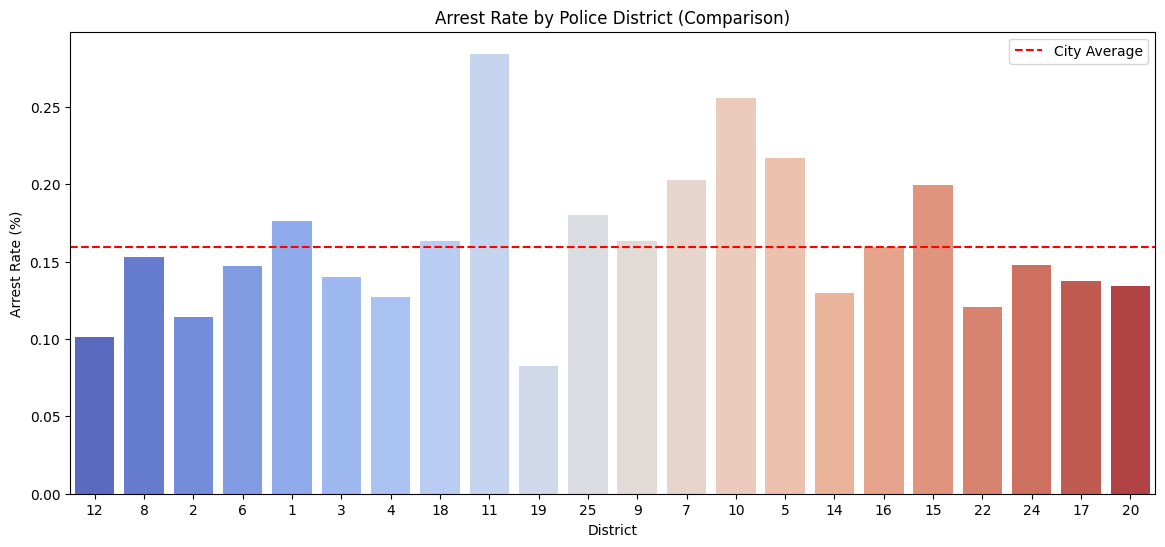

In [6]:
#WEEK 4 --DEEPER ANALYSIS--
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv('data/cleaned_dataset.csv')


# Deeper analysis by District to see arrest distribution
district_analysis = data.groupby('District').agg({
    'ID': 'count',
    'Arrest': 'mean'
}).rename(columns={'ID': 'Total Crimes', 'Arrest': 'Arrest Rate'})

# Sort by crime volume
district_analysis = district_analysis.sort_values(by='Total Crimes', ascending=False)

# Visualization
plt.figure(figsize=(14, 6))
sns.barplot(x=district_analysis.index.astype(str), y=district_analysis['Arrest Rate'], palette='coolwarm')
plt.axhline(data['Arrest'].mean(), color='red', linestyle='--', label='City Average')
plt.title('Arrest Rate by Police District (Comparison)')
plt.ylabel('Arrest Rate (%)')
plt.legend()
plt.savefig('visuals/district_comparison.png')
plt.show()

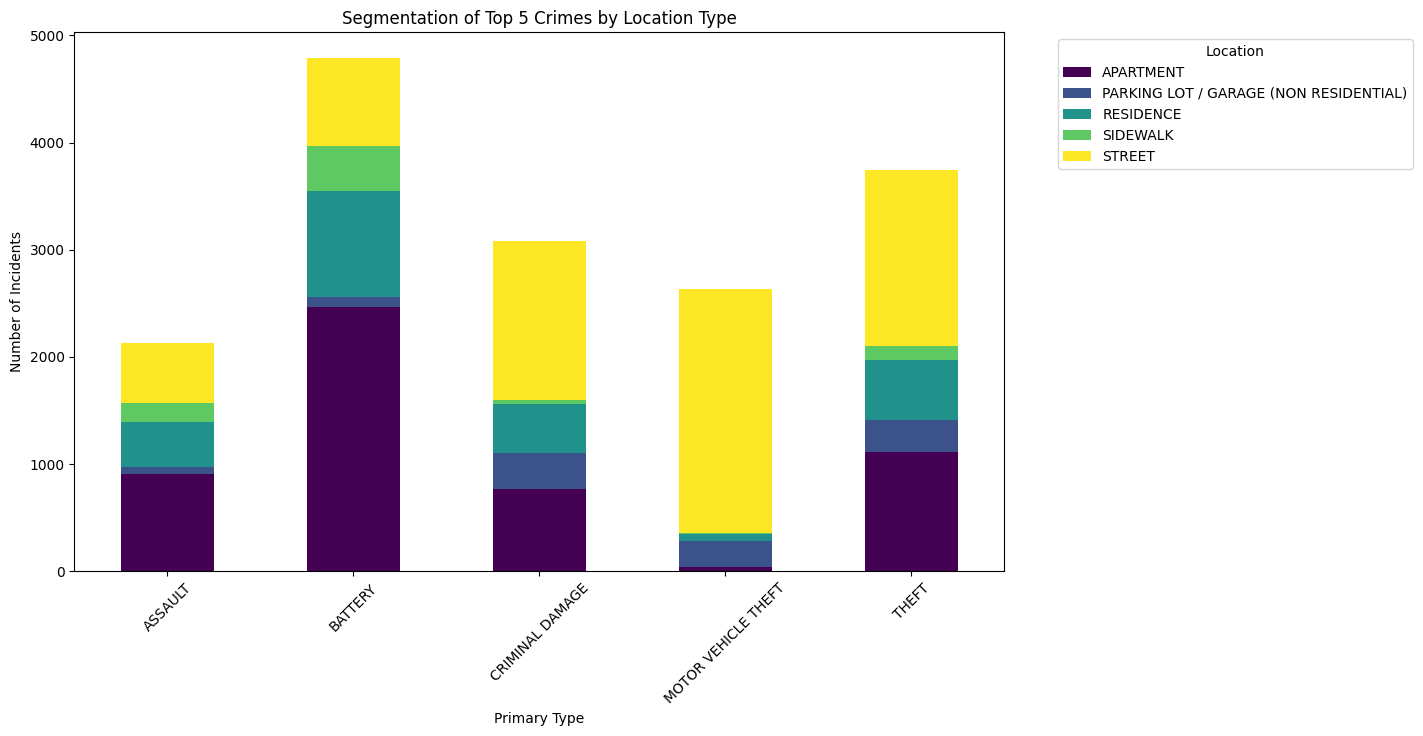

In [9]:
#Deeper analysis by segmentation
# Filter for top categories
top_crimes = data['Primary Type'].value_counts().head(5).index
top_locs = data['Location Description'].value_counts().head(5).index

# Subset the data
segmented_df = data[data['Primary Type'].isin(top_crimes) & data['Location Description'].isin(top_locs)]

# Create a pivot table for the segment visualization
pivot_data = segmented_df.groupby(['Primary Type', 'Location Description']).size().unstack().fillna(0)

# Plotting a stacked bar chart for segmentation
pivot_data.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Segmentation of Top 5 Crimes by Location Type')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.legend(title='Location', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig('visuals/crime_location_segmentation.png', bbox_inches='tight')
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_13156\1447700139.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=district_rank, x='arrest_rate', y=district_rank['District'].astype(str), palette='RdYlGn')


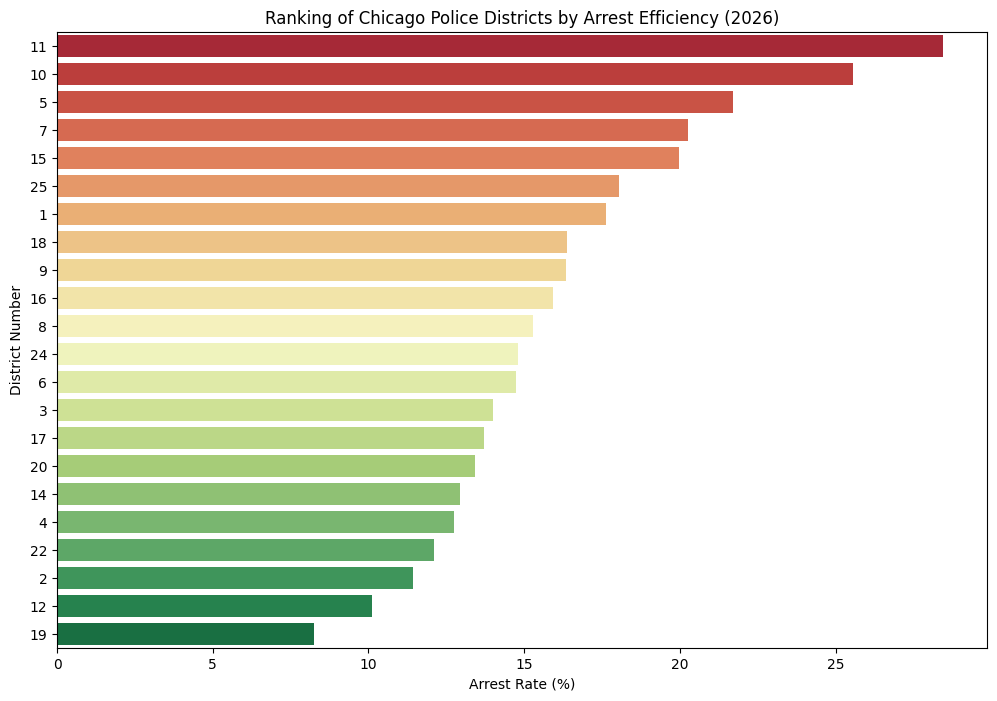

In [8]:
#Deeper analysis by ranking
# total crimes and arrest rate per district
district_rank = data.groupby('District').agg(
    total_crimes=('ID', 'count'),
    arrest_rate=('Arrest', 'mean')
).reset_index()

# Convert arrest rate to percentage
district_rank['arrest_rate'] *= 100

# Rank them by Arrest Rate (Highest to Lowest)
district_rank = district_rank.sort_values(by='arrest_rate', ascending=False)

# Visualization
plt.figure(figsize=(12, 8))
sns.barplot(data=district_rank, x='arrest_rate', y=district_rank['District'].astype(str), palette='RdYlGn')
plt.title('Ranking of Chicago Police Districts by Arrest Efficiency (2026)')
plt.xlabel('Arrest Rate (%)')
plt.ylabel('District Number')

plt.savefig('visuals/district_efficiency_ranking.png')
plt.show()